# Brain Tumor - Support Vector Machine

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,classification_report,confusion_matrix)

In [2]:
df = pd.read_csv(r"C:\Users\Nishant\Downloads\Brain_tumor_Dataset.csv")

In [3]:
df

,Mean_Intensity,Intensity_STD,Texture_Contrast,Homogeneity,Energy,Entropy,Tumor_Area,Perimeter,Tumor_Class
0,104.308184,38.313852,0.779095,0.526627,0.336729,0.852721,554.296077,134.029896,Glioma
1,95.188712,24.479025,0.500130,0.679034,0.712304,0.527192,413.864518,53.708106,Pituitary
2,89.580868,28.586880,0.699354,0.529498,0.481127,0.667449,525.134066,100.309486,Meningioma
3,97.541135,43.966577,0.683458,0.507752,0.298400,0.903507,920.950029,127.684041,Glioma
4,37.044572,12.748645,0.155356,0.837362,0.941177,0.255769,50.227744,11.100774,No Tumor
...,...,...,...,...,...,...,...,...,...
5995,90.157405,38.210089,0.657419,0.711693,0.405964,0.605954,652.081710,97.224107,Meningioma
5996,113.144120,26.114462,0.723225,0.467370,0.295320,0.817170,868.838352,135.753942,Glioma
5997,96.565178,23.193691,0.610370,0.533459,0.382796,0.663959,517.430564,95.410093,Meningioma
5998,108.994253,31.160903,0.731782,0.501071,0.407425,1.063192,572.319574,138.233723,Glioma


In [4]:
df.shape

(6000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mean_Intensity    6000 non-null   float64
 1   Intensity_STD     6000 non-null   float64
 2   Texture_Contrast  6000 non-null   float64
 3   Homogeneity       6000 non-null   float64
 4   Energy            6000 non-null   float64
 5   Entropy           6000 non-null   float64
 6   Tumor_Area        6000 non-null   float64
 7   Perimeter         6000 non-null   float64
 8   Tumor_Class       6000 non-null   object 
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


In [6]:
df.describe

<bound method NDFrame.describe of       Mean_Intensity  Intensity_STD  Texture_Contrast  Homogeneity    Energy  \
0         104.308184      38.313852          0.779095     0.526627  0.336729   
1          95.188712      24.479025          0.500130     0.679034  0.712304   
2          89.580868      28.586880          0.699354     0.529498  0.481127   
3          97.541135      43.966577          0.683458     0.507752  0.298400   
4          37.044572      12.748645          0.155356     0.837362  0.941177   
...              ...            ...               ...          ...       ...   
5995       90.157405      38.210089          0.657419     0.711693  0.405964   
5996      113.144120      26.114462          0.723225     0.467370  0.295320   
5997       96.565178      23.193691          0.610370     0.533459  0.382796   
5998      108.994253      31.160903          0.731782     0.501071  0.407425   
5999       44.375363       7.817331          0.219728     0.774326  0.903306   

     

In [7]:
df.isnull().sum()

Mean_Intensity      0
Intensity_STD       0
Texture_Contrast    0
Homogeneity         0
Energy              0
Entropy             0
Tumor_Area          0
Perimeter           0
Tumor_Class         0
dtype: int64

In [8]:
df = df.drop_duplicates()

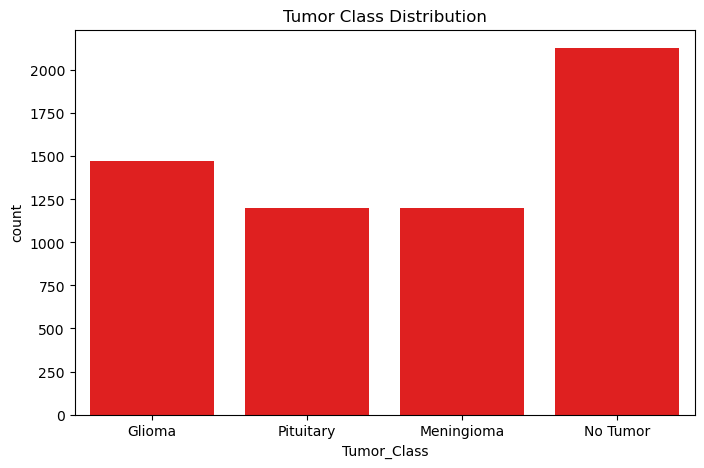

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tumor_Class',color="Red",data=df)
plt.title("Tumor Class Distribution")
plt.show()

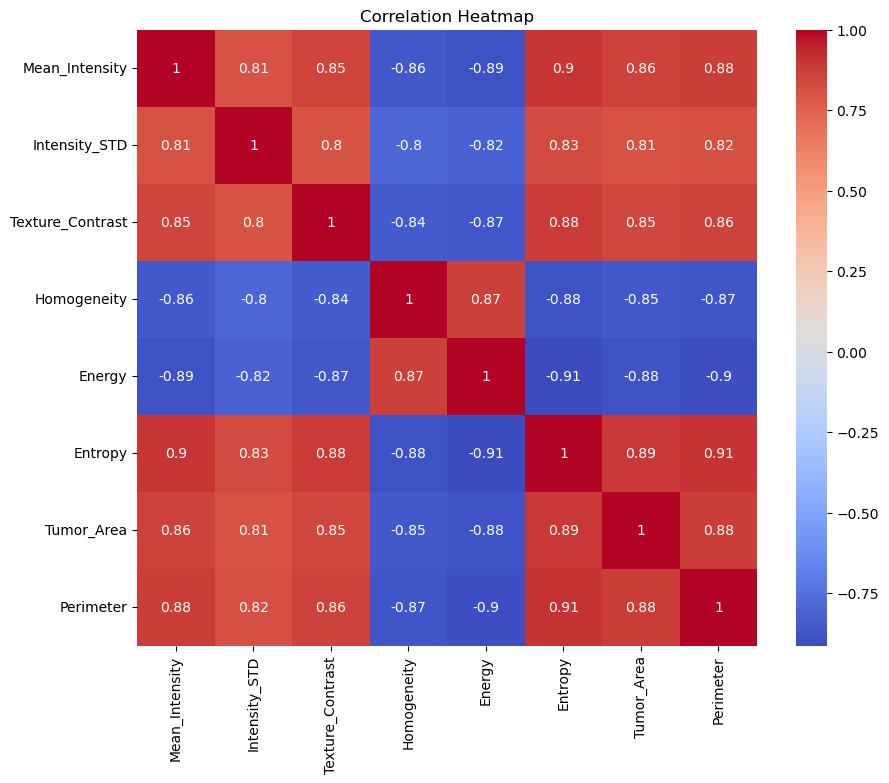

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('Tumor_Class', axis=1).corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

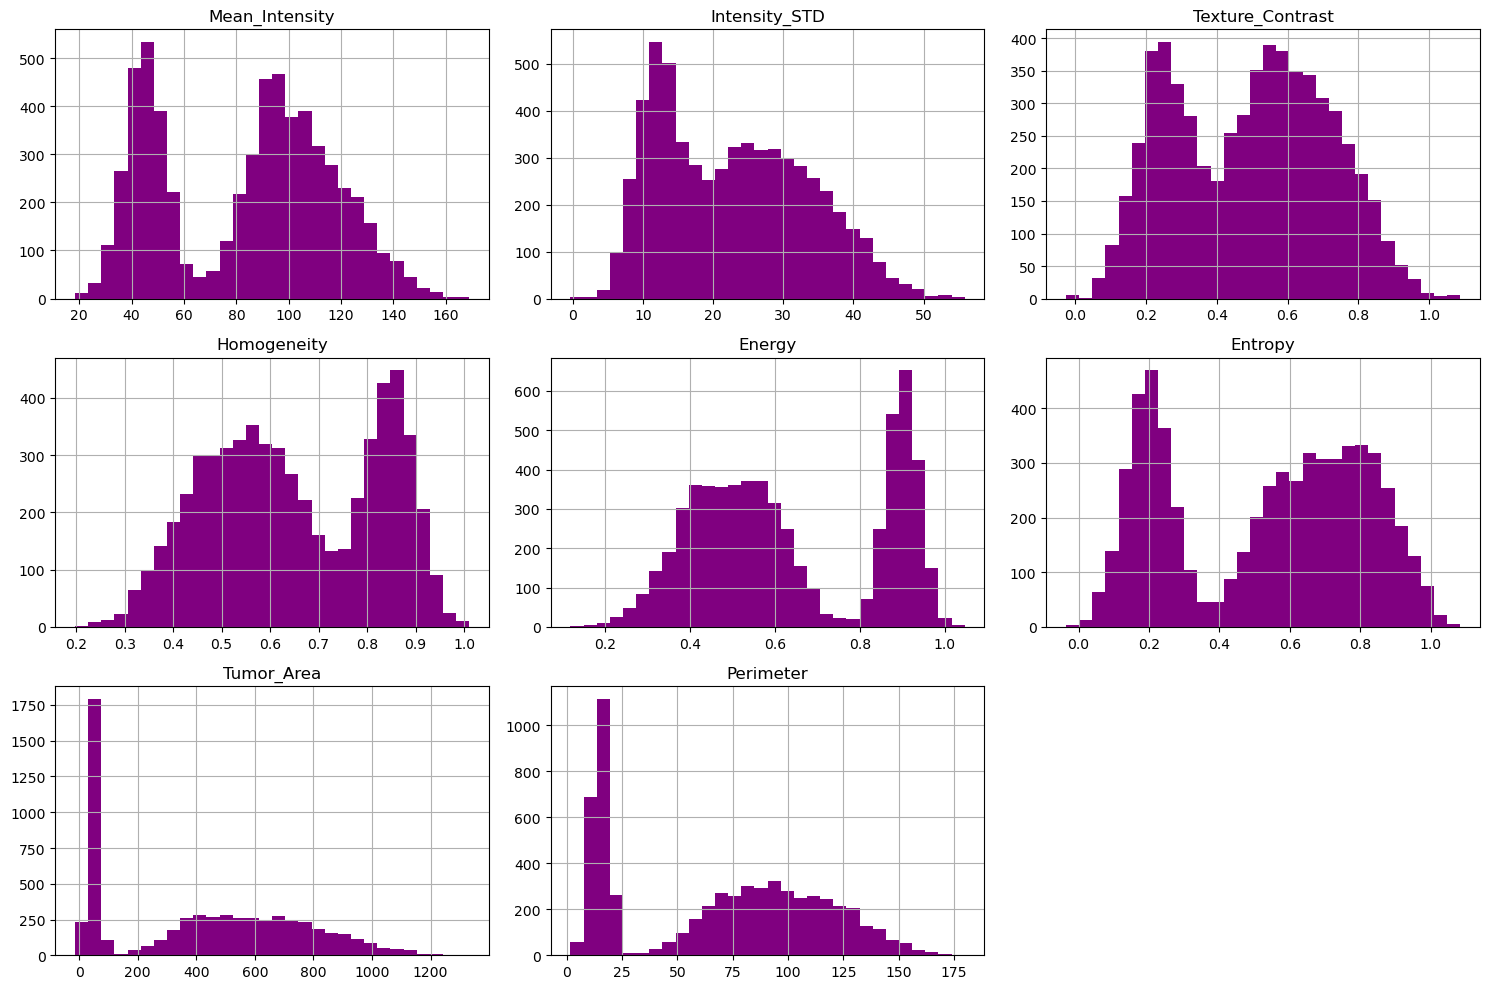

In [11]:
df.hist(figsize=(15,10),color="Purple",bins=30)
plt.tight_layout()
plt.show()

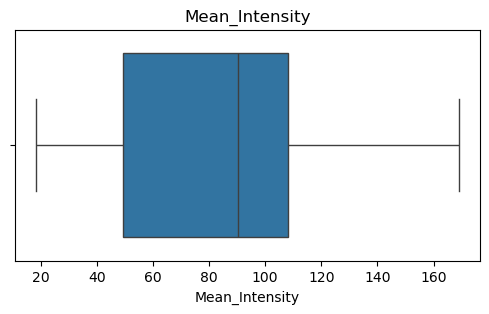

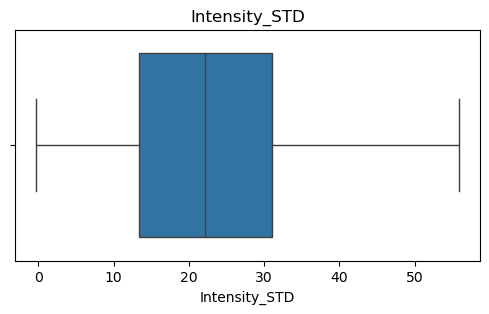

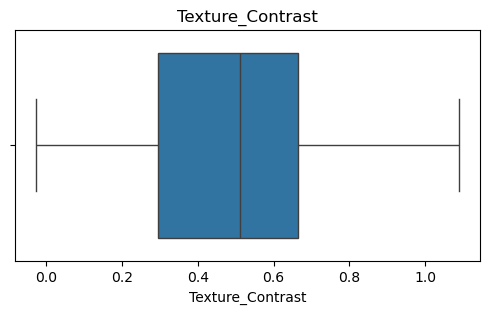

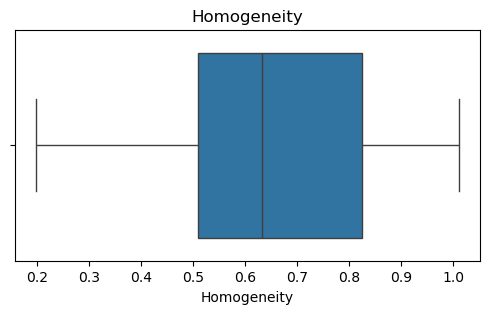

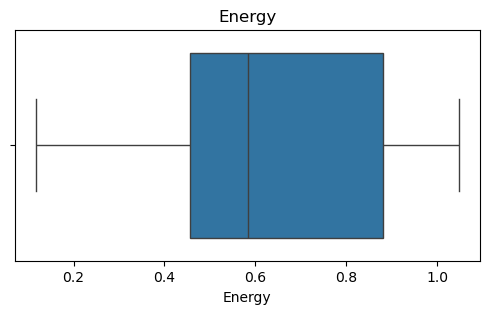

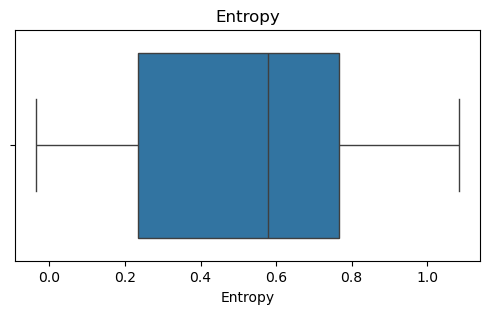

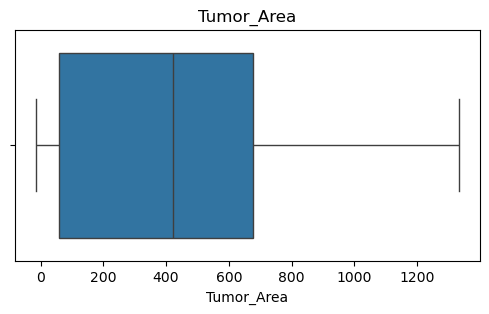

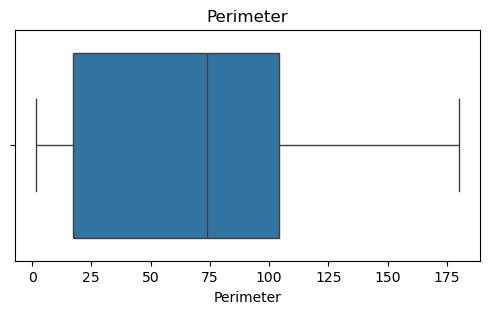

In [12]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [13]:
encoder = LabelEncoder()
df['Tumor_Class'] = encoder.fit_transform(df['Tumor_Class'])
df.head()

,Mean_Intensity,Intensity_STD,Texture_Contrast,Homogeneity,Energy,Entropy,Tumor_Area,Perimeter,Tumor_Class
0,104.308184,38.313852,0.779095,0.526627,0.336729,0.852721,554.296077,134.029896,0
1,95.188712,24.479025,0.500130,0.679034,0.712304,0.527192,413.864518,53.708106,3
2,89.580868,28.586880,0.699354,0.529498,0.481127,0.667449,525.134066,100.309486,1
3,97.541135,43.966577,0.683458,0.507752,0.298400,0.903507,920.950029,127.684041,0
4,37.044572,12.748645,0.155356,0.837362,0.941177,0.255769,50.227744,11.100774,2


In [14]:
for i, label in enumerate(encoder.classes_):
    print(i, ":", label)

0 : Glioma
1 : Meningioma
2 : No Tumor
3 : Pituitary


In [15]:
X = df.drop('Tumor_Class', axis=1)
y = df['Tumor_Class']

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [18]:
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale')
svm_model.fit(X_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
y_pred = svm_model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 97.92 %


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       295
           1       0.95      0.94      0.95       239
           2       1.00      1.00      1.00       426
           3       0.96      0.98      0.97       240

    accuracy                           0.98      1200
   macro avg       0.97      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



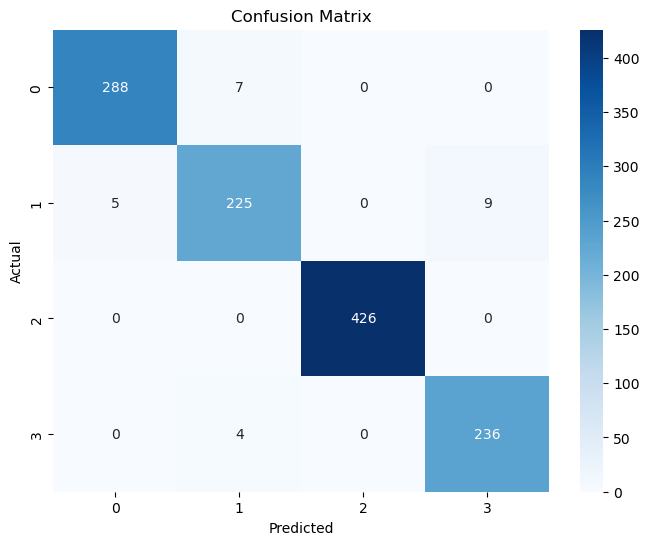

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()